In [120]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('sleep.csv')

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



Столбцы набора данных:  
- ID человека: идентификатор для каждого человека.  
- Пол: пол человека (мужчина/женщина).  
- Возраст: возраст человека в годах.  
- Род занятий: род занятий или профессия человека.  
- Продолжительность сна (часы): количество часов, которые человек спит в день.  
- Качество сна (шкала: 1-10): субъективная оценка качества сна в диапазоне от 1 до 10.  
- Уровень физической активности (минут/день): количество минут, в течение которых человек занимается физической активностью ежедневно.  
- Уровень стресса (шкала: 1-10): субъективная оценка уровня стресса, испытываемого человеком, в диапазоне от 1 до 10.  
- Категория ИМТ: категория индекса массы тела человека (например, недостаточный вес, нормальный вес, избыточный вес).  
- Артериальное давление (систолическое/диастолическое): измерение артериального давления человека, указанное как систолическое давление над диастолическим давлением.  
- Частота сердечных сокращений (уд/мин): частота сердечных сокращений человека в состоянии покоя в ударах в минуту.  
- Ежедневные шаги: количество шагов, которые человек делает за день.  
- Нарушение сна: наличие или отсутствие нарушения сна у человека (отсутствует, бессонница, апноэ во сне).  


### **Выделим и предобработаем целевую переменную: нарушение сна**

In [4]:
df['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

**Заменим nan на 'doesn't have'**

In [5]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("doesn't have")
df['Sleep Disorder'].unique()

array(["doesn't have", 'Sleep Apnea', 'Insomnia'], dtype=object)

In [6]:
sleep_dic = {'Insomnia': 0, "doesn't have":1, 'Sleep Apnea':2}
df['Sleep Disorder'] = df['Sleep Disorder'].map(sleep_dic)

In [7]:
Y = df['Sleep Disorder']
df = df.drop('Sleep Disorder', axis=1)

### **Предобработаю данные**

**Удалю незначащую колокнку с айди и преобразую гендер к бинарному числовому, а не текстовому виду**

In [8]:
df = df.drop('Person ID', axis=1)

In [9]:
df['Gender'] = df['Gender'].map({"Male":0, "Female":1})

In [10]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


**Разобью возраст на категории по 5 лет, тк идейно, что 23, что 24. Разницы большой нет (влияет не возраст в пределах 5 лет, а показатели организма)** 

In [11]:
print(df['Age'].min(), df['Age'].max())

27 59


In [12]:
groups = []
for i in range(df['Age'].min() - 1, df['Age'].max() + 5, 5):
    groups.append(i)
groups_cut = pd.cut(df['Age'].values, groups)
df['Age'] = groups_cut.codes

In [13]:
print(df['Age'].min(), df['Age'].max())

0 6


In [14]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,0,0,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,0,0,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,0,0,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,0,0,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


In [15]:
df['Occupation'].unique()

array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
       'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
       'Salesperson', 'Manager'], dtype=object)

**Нельзя как-то эмпирически разделить эти профессии однозначно, поэтому воспользуюсь просто лейбл декодером**

In [16]:

le = LabelEncoder()
le.fit(df['Occupation'].unique())
le.classes_

array(['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse',
       'Sales Representative', 'Salesperson', 'Scientist',
       'Software Engineer', 'Teacher'], dtype=object)

In [17]:
df['Occupation'] = le.transform(df['Occupation'])

In [18]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,6.1,6,42,6,Overweight,126/83,77,4200
1,0,0,1,6.2,6,60,8,Normal,125/80,75,10000
2,0,0,1,6.2,6,60,8,Normal,125/80,75,10000
3,0,0,6,5.9,4,30,8,Obese,140/90,85,3000
4,0,0,6,5.9,4,30,8,Obese,140/90,85,3000


**Разобьем сон на группы с ходом 0.5 (фазы сна)**

In [19]:
print(df['Sleep Duration'].min(), df['Sleep Duration'].max())

5.8 8.5


In [20]:
df['Sleep Duration'] = df['Sleep Duration'] * 10

In [21]:
groups = []
for i in range(54, 90, 5):
    groups.append(i)
groups_cut = pd.cut(df['Sleep Duration'].values, groups)
df['Sleep Duration'] = groups_cut.codes

In [22]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,1,6,42,6,Overweight,126/83,77,4200
1,0,0,1,1,6,60,8,Normal,125/80,75,10000
2,0,0,1,1,6,60,8,Normal,125/80,75,10000
3,0,0,6,0,4,30,8,Obese,140/90,85,3000
4,0,0,6,0,4,30,8,Obese,140/90,85,3000


**Закодирую Категория ИМТ**

In [23]:
le2 = LabelEncoder()
le2.fit(df['BMI Category'].unique())
df['BMI Category'] = le2.transform(df['BMI Category'])

In [24]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,1,6,42,6,3,126/83,77,4200
1,0,0,1,1,6,60,8,0,125/80,75,10000
2,0,0,1,1,6,60,8,0,125/80,75,10000
3,0,0,6,0,4,30,8,2,140/90,85,3000
4,0,0,6,0,4,30,8,2,140/90,85,3000


**Предобработаю давление**

In [25]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

In [26]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Systolic,Diastolic
0,0,0,9,1,6,42,6,3,126/83,77,4200,126,83
1,0,0,1,1,6,60,8,0,125/80,75,10000,125,80
2,0,0,1,1,6,60,8,0,125/80,75,10000,125,80
3,0,0,6,0,4,30,8,2,140/90,85,3000,140,90
4,0,0,6,0,4,30,8,2,140/90,85,3000,140,90


In [27]:
df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)

In [28]:
def determine_pressure_status(row):
    systolic = row['Systolic']
    diastolic = row['Diastolic']
    if systolic < 90 or diastolic < 60:
        return -1  # Пониженное давление
    elif systolic > 120 or diastolic > 80:
        return 1   # Повышенное давление
    else:
        return 0   # Нормальное давление
df['PressureStatus'] = df.apply(determine_pressure_status, axis=1)

In [29]:
df = df.drop(['Blood Pressure', 'Systolic', 'Diastolic'], axis=1)


In [30]:
df['Daily Steps'].unique()

array([ 4200, 10000,  3000,  3500,  8000,  4000,  4100,  6800,  5000,
        7000,  5500,  5200,  5600,  3300,  4800,  7500,  7300,  6200,
        6000,  3700])

In [31]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,PressureStatus
0,0,0,9,1,6,42,6,3,77,4200,1
1,0,0,1,1,6,60,8,0,75,10000,1
2,0,0,1,1,6,60,8,0,75,10000,1
3,0,0,6,0,4,30,8,2,85,3000,1
4,0,0,6,0,4,30,8,2,85,3000,1


**Проверим на наличие пропусков в данных**

In [32]:
df.isna().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
PressureStatus             0
dtype: int64

## **Разобью данные на тренировочные и тестовые**

In [33]:
x_train, x_test, y_train, y_test = train_test_split(df, Y, test_size = 0.3, stratify=Y)

## **Логистическая регрессия**

In [34]:
clf = LogisticRegression(random_state=0, max_iter=1000000, C=1)
clf = clf.fit(x_train, y_train)
train_predict = clf.predict(x_train)
test_predict = clf.predict(x_test)

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
from sklearn.metrics import f1_score
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.8689089400085965
0.8636967425999723


**Заскалирую данные**

In [116]:
scale_features = ["Age", "Physical Activity Level", "Heart Rate", "Daily Steps", "Quality of Sleep", "Sleep Duration"]
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')  # Оставляем остальные признаки без изменений
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=10000, C=0.04))
])
pipeline.fit(x_train, y_train)

train_predict = pipeline.predict(x_train)
test_predict = pipeline.predict(x_test)

In [117]:
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.8557276057276058
0.8961538461538461


**One-vs-all**

In [76]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')  

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=10000, multi_class='ovr', C=0.1)) 
])

pipeline.fit(x_train, y_train)
train_predict = pipeline.predict(x_train)
test_predict = pipeline.predict(x_test)

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [77]:
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.8555773367094122
0.88164378681096


**ALL-vs-ALL**

In [118]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough') 
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=10000, multi_class='multinomial', solver='lbfgs', C=0.03))  # All-vs-All (OvO)
])
pipeline.fit(x_train, y_train)
train_predict = pipeline.predict(x_train)
test_predict = pipeline.predict(x_test)

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [119]:
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.8557276057276058
0.8961538461538461


## **K ближайших соседей**

In [162]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')  

# Построение пайплайна
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=7)) 
])
pipeline.fit(x_train, y_train)
train_predict = pipeline.predict(x_train)
test_predict = pipeline.predict(x_test)

In [163]:
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.8857272976735732
0.8855477855477855


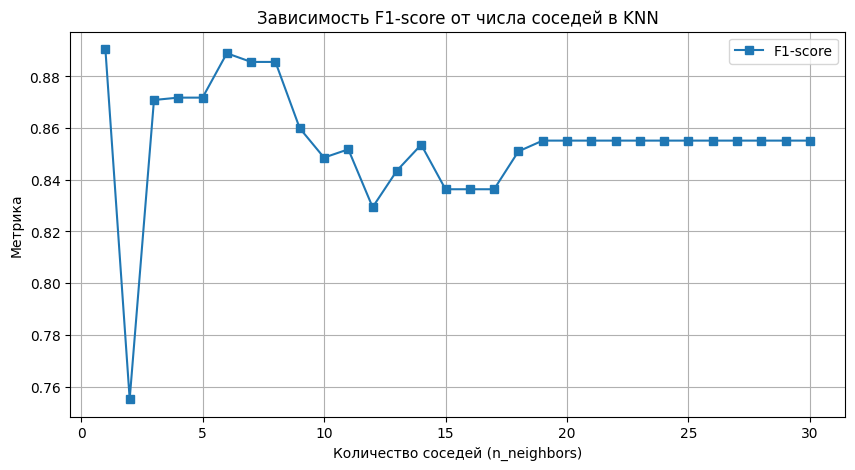

In [167]:
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')

f1_scores = []
for n in range(1, 31):
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=n))
    ])
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    f1_scores.append(f1_score(y_test, y_pred, average='macro'))  
plt.figure(figsize=(10, 5))
plt.plot(neighbors_range, f1_scores, label="F1-score", marker='s')
plt.xlabel("Количество соседей (n_neighbors)")
plt.ylabel("Метрика")
plt.title("Зависимость F1-score от числа соседей в KNN")
plt.legend()
plt.grid()
plt.show()

## **Дерево решений**

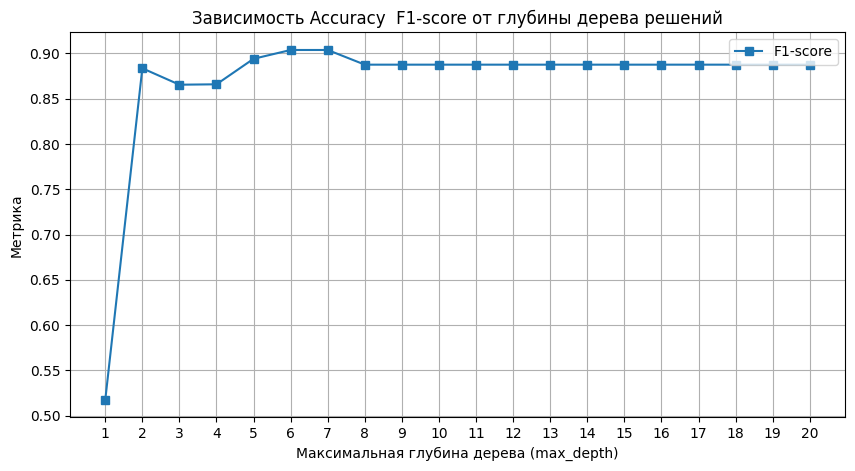

In [169]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
f1_scores = []
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')
for depth in range(1, 21):
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    f1_scores.append(f1_score(y_test, y_pred, average='macro')) 

plt.figure(figsize=(10, 5))
plt.plot(depth_range, f1_scores, label="F1-score", marker='s')
plt.xlabel("Максимальная глубина дерева (max_depth)")
plt.xticks(np.arange(1, 21, step=1))
plt.ylabel("Метрика")
plt.title("Зависимость Accuracy  F1-score от глубины дерева решений")
plt.legend()
plt.grid()
plt.show()

In [170]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')  

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42)) 
])
pipeline.fit(x_train, y_train)
train_predict = pipeline.predict(x_train)
test_predict = pipeline.predict(x_test)

In [171]:
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.9096575110942194
0.9038184038184038
